In [1]:
#importing relevant packages
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import *
from sklearn import *
from sklearn import linear_model, model_selection, metrics
#import lime, lime.lime_tabular
from imblearn.over_sampling import RandomOverSampler


In [2]:
#getting the data and performing some transformations
ifood_origin = pd.read_csv("C:/Users/user/Desktop/Data_Stuffs/Portfolio_Projects/EDA/Marketing_analytics - ifood/ml_project1_data.csv")
ifood = pd.read_csv("C:/Users/user/Desktop/Data_Stuffs/Portfolio_Projects/EDA/Marketing_analytics - ifood/ml_project1_data.csv", parse_dates = ['Dt_Customer'])


In [ ]:
##doing a check of the dataset and the relevant details and types surrounding the columns
##cleaning data by removing any irrelevant nans
print(ifood.isnull().sum(axis = 0))
print(ifood['Income'].isnull().sum() / np.prod(ifood.shape) * 100)
ifood = ifood.dropna(how = 'any')
ifood = ifood[ifood['Income'].isnull() == False]
print(ifood.isnull().sum(axis = 0))
print(ifood.nunique(axis = 0))
print(ifood.dtypes)
print(ifood.describe())

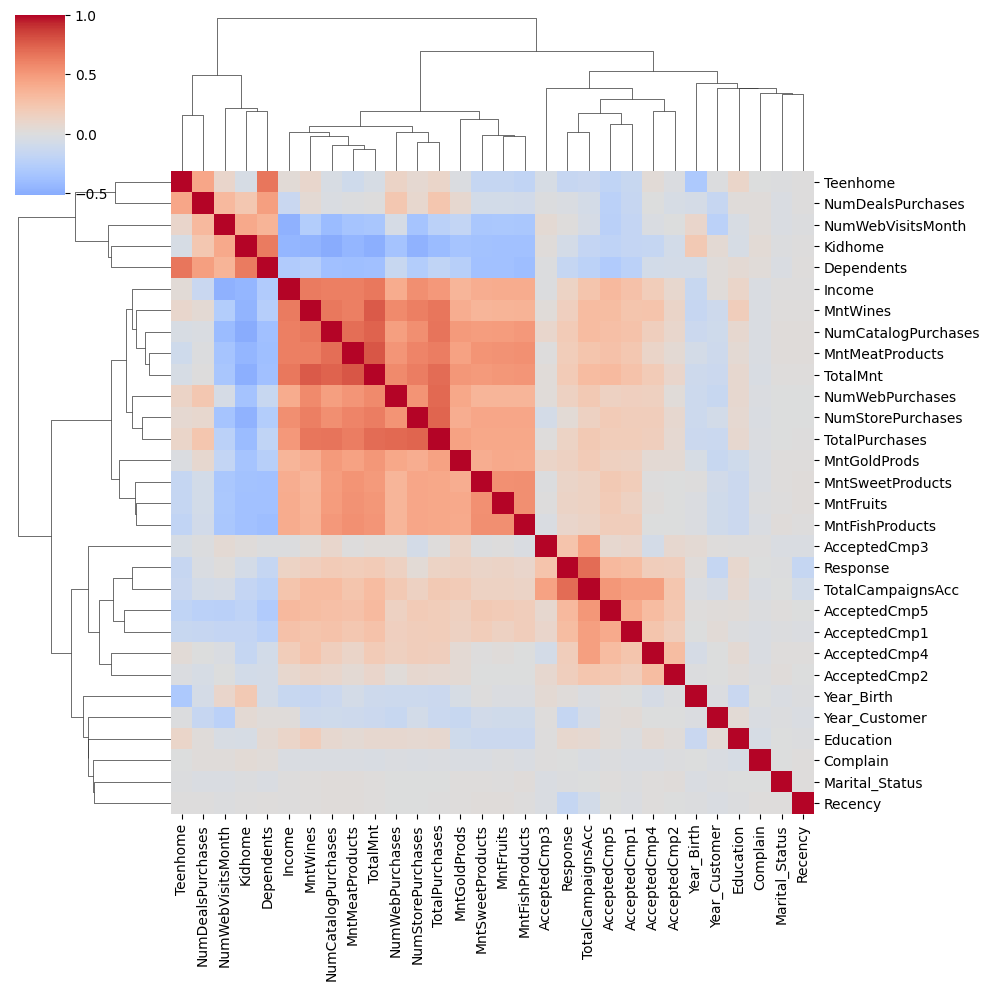

In [4]:
#doing transformation of columns.
"""
Adding additional columns as changed types, doing specific addition
or mathematical functions to retrieve more useful information
"""
ifood['Income'] = ifood['Income'].astype('float64')
ifood['Dependents'] = ifood['Kidhome'] + ifood['Teenhome'] #good to just combine with total number of dependents
ifood['Year_Customer'] = ifood['Dt_Customer'].dt.year #getting the year
Col_with_purchase = [col for col in ifood.columns if 'Purchase' in col]
ifood['TotalPurchases'] = ifood.loc[:,Col_with_purchase].sum(axis = 1) #getting totalpurchases?
Mnt_with_purchase = [col for col in ifood.columns if 'Mnt' in col]
ifood['TotalMnt'] = ifood.loc[:, Mnt_with_purchase].sum(axis = 1)
Cmp_or_Response = [col for col in ifood.columns if 'Cmp' in col or 'Response' in col]
ifood['TotalCampaignsAcc'] = ifood.loc[:, Cmp_or_Response].sum(axis = 1)
labelencode = preprocessing.LabelEncoder()
ifood['Education'] = labelencode.fit_transform(ifood['Education'])
ifood['Marital_Status'] = labelencode.fit_transform(ifood['Marital_Status'])
#print(ifood['Z_CostContact'])

#doing a generic multivariate EDA - heatmap
correlation = ifood.drop(columns = ['ID', 'Z_CostContact', 'Z_Revenue', 'Country']).select_dtypes(np.number).corr(method = 'kendall')
#print(correlation)
'''why use kendall - because of non-linearity concerns, in which Pearson's is more evident or appropriate to use for linear relationships'''
'''note also numerical and ordinal (ranked) concerns. If it is numerical, usually Pearson's corr is used, if not then Kendall or Spearman. But kendall is more robust'''
axis_correlation = sns.clustermap(correlation, cmap = 'coolwarm', center = 0)
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_19380\3385285972.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_yticklabels(ax[0,0].get_yticklabels(), fontsize=50)
C:\Users\user\AppData\Local\Temp\ipykernel_19380\3385285972.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), fontsize=50)
C:\Users\user\AppData\Local\Temp\ipykernel_19380\3385285972.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_yticklabels(ax[0,1].get_yticklabels(), fontsize=50)
C:\Users\user\AppData\Local\Temp\ipykernel_19380\3385285972.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklab

Text(0, 0.5, 'Income')

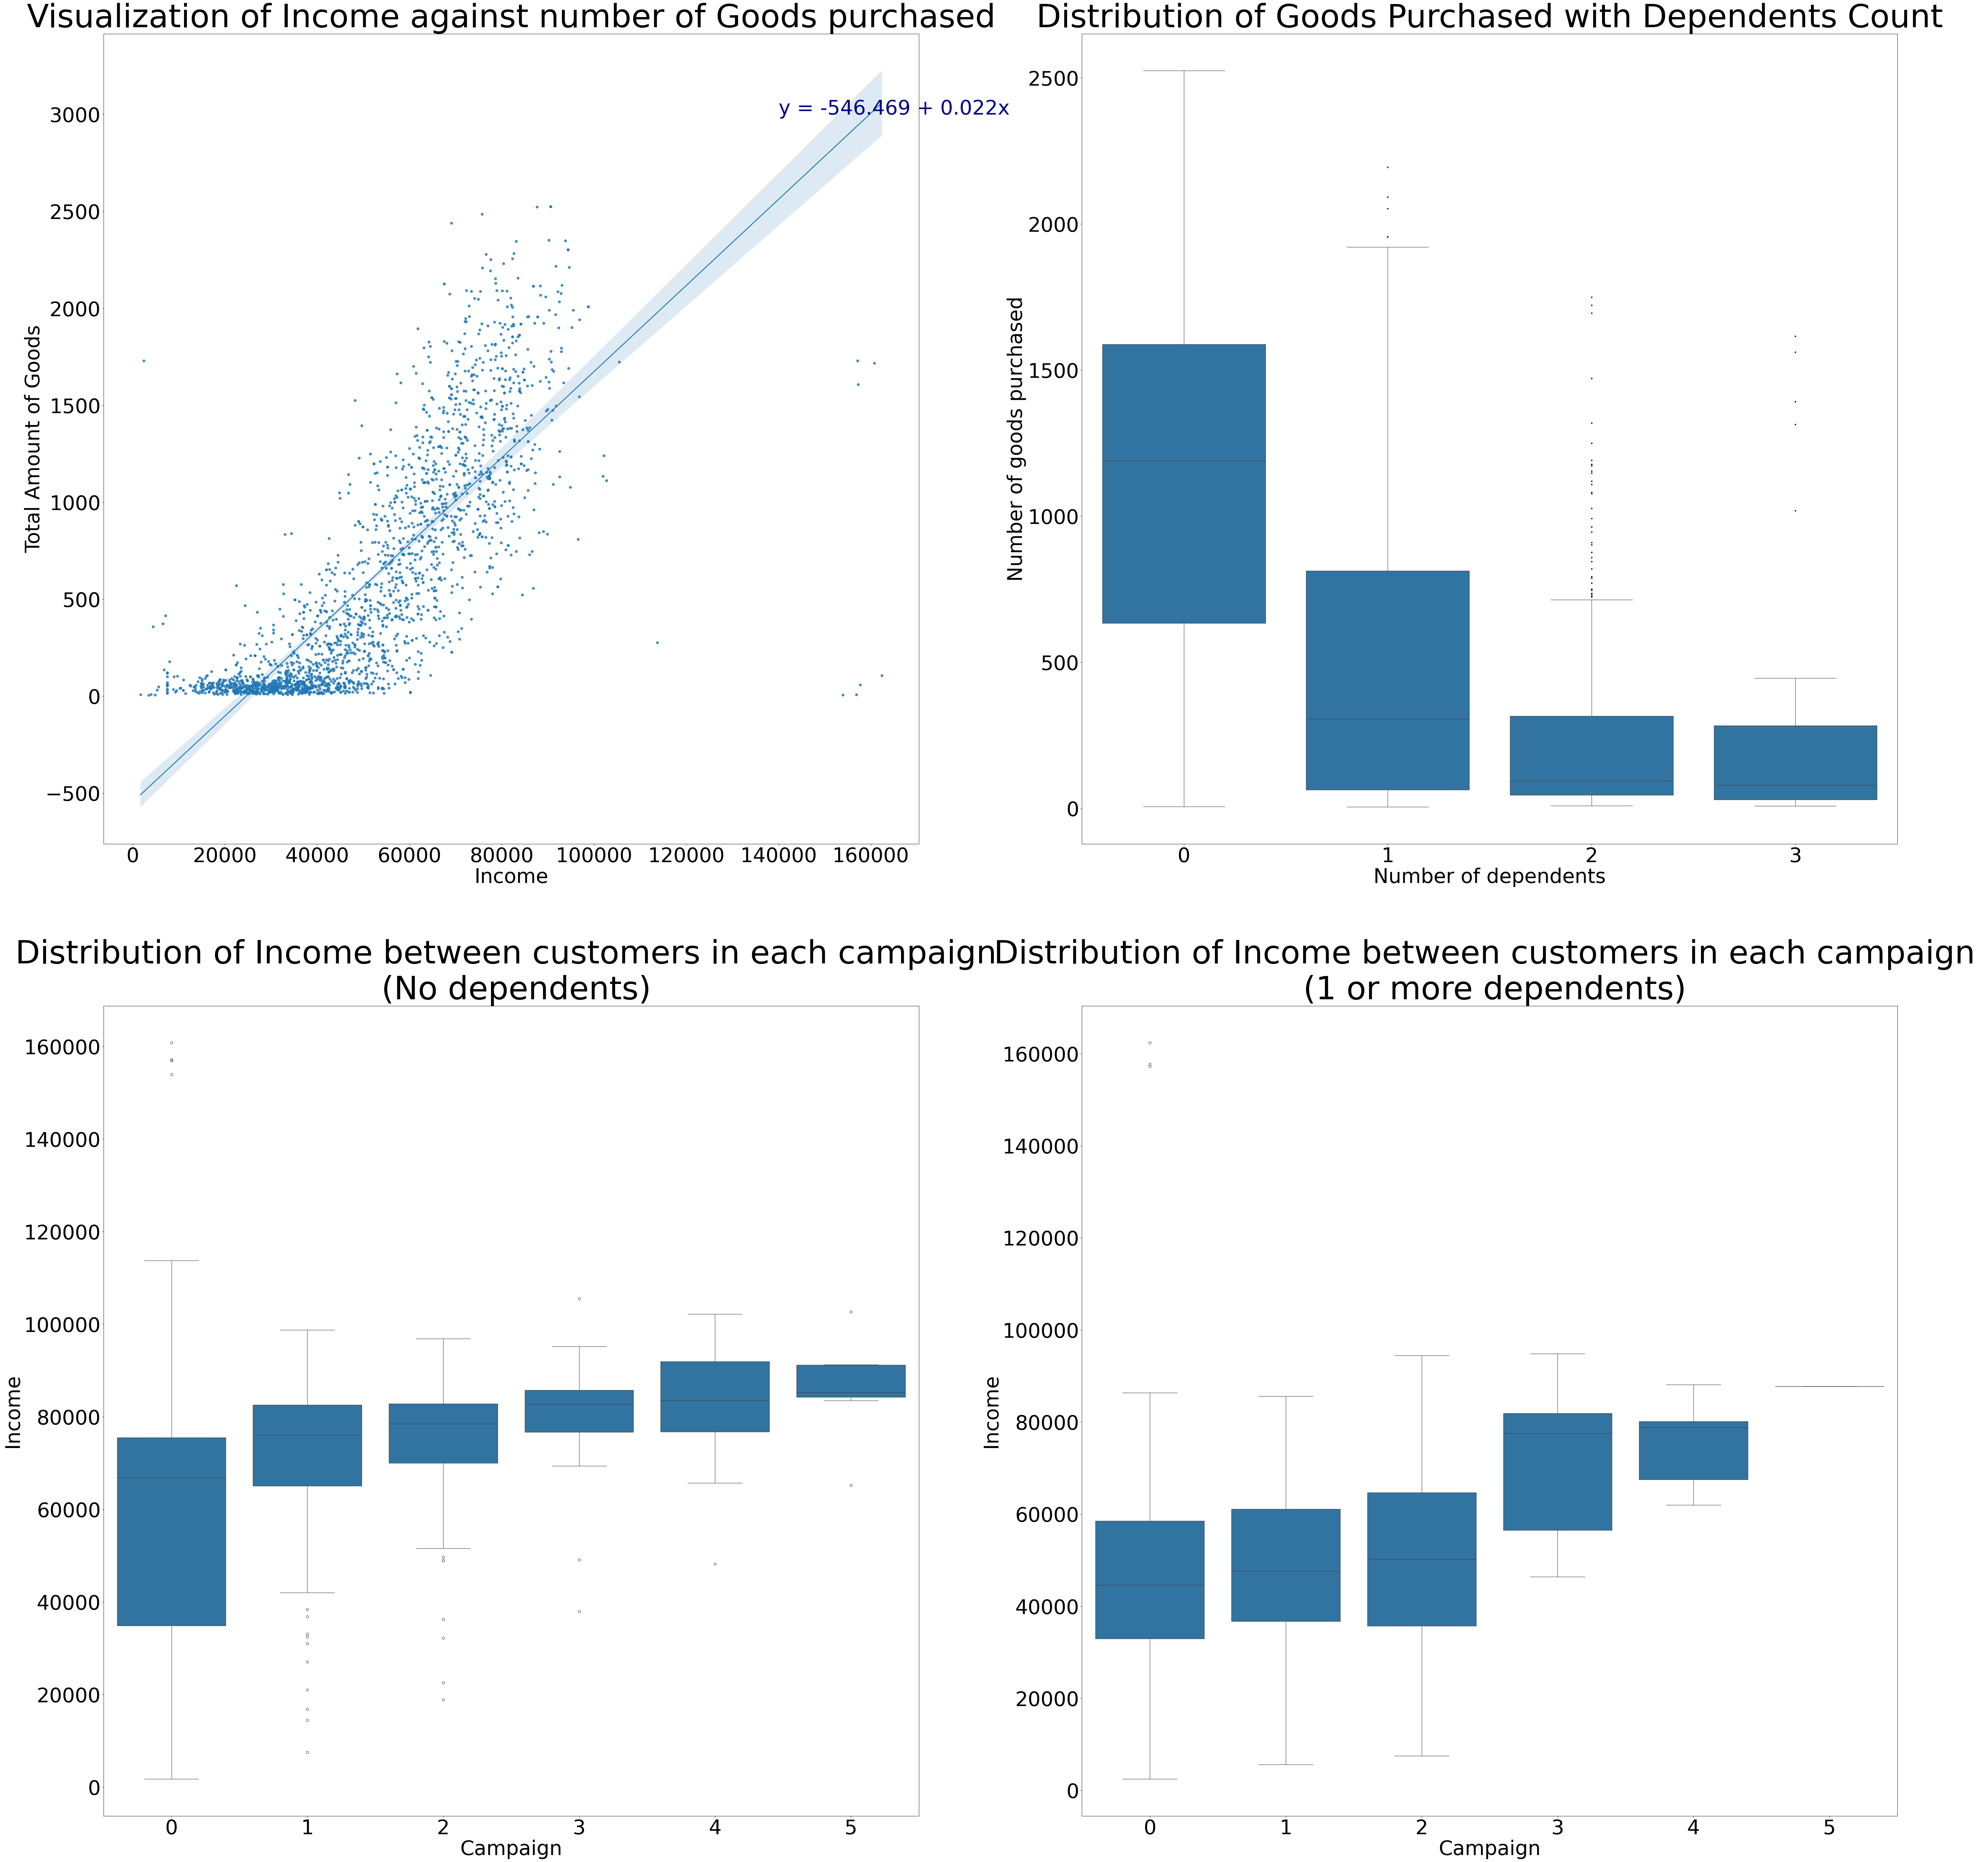

In [8]:
'''based on heatmap:
1. income actually has a positive correlation to purchases (any)
2. number of dependents has a positive correlation to number of deal purchases and visits, but negative towards all other purchases
3. Campaigns are quite correlated to each other'''
#finding more correlation using bivariate or univariate analysis
fig, ax = plt.subplots(2,2, figsize=(80,80))
#1. doing regplot for comparison of income with purchases
p1 = sns.regplot(x = 'Income', y = 'TotalMnt', data = ifood[ifood['Income'] < 200000], ax=ax[0,0])
slope, intercept, r, p, sterr = scipy.stats.linregress(x = p1.get_lines()[0].get_xdata(), y = p1.get_lines()[0].get_ydata())
ax[0,0].text(140000, 3000,
             f'y = {intercept:.3f} + {slope:.3f}x',
             fontsize=50, color='darkblue')
ax[0,0].set_yticklabels(ax[0,0].get_yticklabels(), fontsize=50)
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), fontsize=50)
p1.set_title("Visualization of Income against number of Goods purchased", fontsize=80)
p1.set_ylabel("Total Amount of Goods", fontsize=50)
p1.set_xlabel("Income", fontsize=50)

#2. doing multiple boxplot for comparison of dependents on expenditure
plot2 = sns.boxplot(x = 'Dependents', y = 'TotalMnt', data = ifood, flierprops = {'marker': '.', 'markerfacecolor': 'black'}, ax=ax[0,1])
ax[0,1].set_yticklabels(ax[0,1].get_yticklabels(), fontsize=50)
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), fontsize=50)
plot2.set_title("Distribution of Goods Purchased with Dependents Count", fontsize=80)
plot2.set_ylabel("Number of goods purchased", fontsize=50)
plot2.set_xlabel("Number of dependents", fontsize=50)

#3. having kids and teens on campaign acceptance
plot3 = sns.boxplot(x = 'TotalCampaignsAcc', y = 'Income', data = ifood[(ifood['Income'] < 200000) & (ifood['Dependents'] == 0)], ax=ax[1,0])
ax[1,0].set_yticklabels(ax[1,0].get_yticklabels(), fontsize=50)
ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), fontsize=50)
plot3.set_title("Distribution of Income between customers in each campaign \n (No dependents)", fontsize=80)
plot3.set_xlabel("Campaign", fontsize=50)
plot3.set_ylabel("Income", fontsize=50)


plot4 = sns.boxplot(x = 'TotalCampaignsAcc', y = 'Income', data = ifood[(ifood['Income'] < 200000) & (ifood['Dependents'] > 0)], ax=ax[1,1])
ax[1,1].set_yticklabels(ax[1,1].get_yticklabels(), fontsize=50)
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), fontsize=50)
plot4.set_title("Distribution of Income between customers in each campaign \n (1 or more dependents)", fontsize=80)
plot4.set_xlabel("Campaign", fontsize=50)
plot4.set_ylabel("Income", fontsize=50)

In [10]:
ifood_train_test = ifood.drop(columns = ['ID', 'Z_CostContact', 'Z_Revenue', 'Country']).select_dtypes(np.number)
purchases = [col for col in ifood if 'Purchases' in col] + ['Year_Customer']

In [33]:
linear = linear_model.LinearRegression()
print(ifood_train_test.columns)
X = ifood_train_test[['Income','NumWebVisitsMonth','Complain', 'Recency']]
#X = ifood_train_test.loc[:,purchases]
y = ifood_train_test['TotalMnt']
#just using a minmaxscaler for normalization and normalization
scaler = preprocessing.StandardScaler()
X_scale = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_scale, y, test_size= 0.3, random_state= 1)
reg = linear.fit(X_train, y_train)
y_pred = reg.predict(X_test)
r2 = metrics.r2_score(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'r2-score: {r2:.4f}')
print(f'Mean squared error: {mse:.4f}')
print(f'Root mean squared error: {rmse:.4f}')

#using permutation feature importance? What it means:
''' Model inspection technique that measure contribution of each feature to a fitted model - useful for non-linear or opaque estimators'''
'''this is done by comparing your target variable (Y) with multiple independent variables,
then calculating increase of the model's prediction error (or decrease) through multiple combinations of testing with varying number of estimator variables'''
"""
result = inspection.permutation_importance(reg, X_test, y_test, n_repeats = 10, random_state = 1)

features = pd.DataFrame({'Feature_Name':[], 'Error_Mean':[], 'Error_std': []})

for i in range(len(result.importances_mean)):
    features.loc[len(features)] = [X.columns[i], result.importances_mean[i], result.importances_std[i]]

print(features.sort_values(by = 'Error_Mean', ascending = False))

for i in range(len(result.importances_mean)):
    print(f"{correlation.columns[i]:<8}" + ' '
              f"{result.importances_mean[i]:.3f}"
              f" +/- {result.importances_std[i]:.3f}")

#result: most important features are purchases and purchases counts.

"""

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Dependents', 'Year_Customer', 'TotalPurchases',
       'TotalMnt', 'TotalCampaignsAcc'],
      dtype='object')
r2-score: -0.2249
Mean squared error: 448577.9952
Root mean squared error: 669.7597


'\nresult = inspection.permutation_importance(reg, X_test, y_test, n_repeats = 10, random_state = 1)\n\nfeatures = pd.DataFrame({\'Feature_Name\':[], \'Error_Mean\':[], \'Error_std\': []})\n\nfor i in range(len(result.importances_mean)):\n    features.loc[len(features)] = [X.columns[i], result.importances_mean[i], result.importances_std[i]]\n\nprint(features.sort_values(by = \'Error_Mean\', ascending = False))\n\nfor i in range(len(result.importances_mean)):\n    print(f"{correlation.columns[i]:<8}" + \' \'\n              f"{result.importances_mean[i]:.3f}"\n              f" +/- {result.importances_std[i]:.3f}")\n\n#result: most important features are purchases and purchases counts.\n\n'

In [30]:
#doing a SHAP/Lime plot for absolute differences (to find relative signs - increase or decrease)
#explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names = X.columns,                                               class_names = ['MEDV'], verbose = True, mode = 'regression')
#print(X_train, X_test)
#exp = explainer.explain_instance(X_test.values[5], y_pred, num_features = 5)
#exp.show_in_notebook(show_table = True)

In [31]:
#check for imbalance.
ifood_grp = ifood.groupby('AcceptedCmp5')['ID'].count()
print(ifood_grp)

AcceptedCmp5
0    2054
1     162
Name: ID, dtype: int64


In [ ]:
#can do logistic regression to check for feature importances and decide if certain campaigns
##are affected by which parameters
logistic = linear_model.LogisticRegression(solver='liblinear')
x = ifood_train_test.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'TotalCampaignsAcc'])
y1 = ifood_train_test['AcceptedCmp1']
y2 = ifood_train_test['AcceptedCmp2']
y3 = ifood_train_test['AcceptedCmp3']
y4 = ifood_train_test['AcceptedCmp4']
y5 = ifood_train_test['AcceptedCmp5']

ros = RandomOverSampler(random_state=1010)
#x_over, y1_over = ros.fit_resample(x,y1)
#do 5 different logistics test based on campaign. See which features may be important
X_train, X_test, y1_train, y1_test = model_selection.train_test_split(x, y1, train_size=0.3, random_state=42)
logistic1 = logistic.fit(X_train, y1_train)
y1_pred = logistic1.predict(X_test)
feature_names = x.columns
coefficients = logistic1.coef_[0]
print("y1" + " " + str(metrics.accuracy_score(y1_test, y1_pred)))
print("y1" + " " + str(metrics.classification_report(y1_test, y1_pred)))

#sorted_indices = abs(coefficients).argsort()[::-1]
#for i in sorted_indices:
#    print(f"{feature_names[i]}: {coefficients[i]:.4f}")

"""
Findings from first campaign:
1. Seems to be related to the years in which individual became a customer
2. Positively related to Catalog Purchases and Negatively to Deals.
3. Negaitvely related to Education Status and Marital Status as well.
"""

X_train, X_test, y2_train, y2_test = model_selection.train_test_split(x, y2, train_size=0.3, random_state=42)
logistic2 = logistic.fit(X_train, y2_train)
y2_pred = logistic1.predict(X_test)
feature_names = x.columns
coefficients = logistic2.coef_[0]
print("y2" + " " + str(metrics.accuracy_score(y2_test, y2_pred)))
print("y2" + " " + str(metrics.classification_report(y2_test, y2_pred)))

#sorted_indices = abs(coefficients).argsort()[::-1]
#for i in sorted_indices:
#    print(f"{feature_names[i]}: {coefficients[i]:.4f}")

"""
1. Campaign 2 seems to be highly effective or attractive to customers - seems to be positively correlated
to purchase numbers in every platform (Web, Catalog, Store)
1.1 It may be highly effective for huge purchases as well.
2. Still quite negatively related to Education and Marital Status (would need to see their label encoders)
3. A little postively related to Wine, Fish, Fruit and Sweets purchases
"""

X_train, X_test, y3_train, y3_test = model_selection.train_test_split(x, y3, train_size=0.3, random_state=42)
logistic3 = logistic.fit(X_train, y3_train)
y3_pred = logistic1.predict(X_test)
feature_names = x.columns
coefficients = logistic2.coef_[0]
print("y3" + " " + str(metrics.accuracy_score(y3_test, y3_pred)))
print("y3" + " " + str(metrics.classification_report(y3_test, y3_pred)))

#sorted_indices = abs(coefficients).argsort()[::-1]
#for i in sorted_indices:
#    print(f"{feature_names[i]}: {coefficients[i]:.4f}")


"""
1. Campaign 3 seems to be positively related to Gold products. Maybe targeted at this group
2. Negatively related to sweets and fish. For some weird reason
3. Education seems to be positively related to campaign 3 for once
"""

X_train, X_test, y4_train, y4_test = model_selection.train_test_split(x, y4, train_size=0.3, random_state=42)
logistic4 = logistic.fit(X_train, y4_train)
y4_pred = logistic1.predict(X_test)
feature_names = x.columns
coefficients = logistic2.coef_[0]
print("y4" + " " + str(metrics.accuracy_score(y4_test, y4_pred)))
print("y4" + " " + str(metrics.classification_report(y4_test, y4_pred)))

#sorted_indices = abs(coefficients).argsort()[::-1]
#for i in sorted_indices:
#    print(f"{feature_names[i]}: {coefficients[i]:.4f}")


"""
Generally pale in test - campaign might not be very effective throughout
"""

X_train, X_test, y5_train, y5_test = model_selection.train_test_split(x, y5, train_size=0.2, random_state=42)
logistic4 = logistic.fit(X_train, y5_train)
y5_pred = logistic1.predict(X_test)
feature_names = x.columns
coefficients = logistic2.coef_[0]
print("y5" + " " + str(metrics.accuracy_score(y5_test, y5_pred)))
print("y5" + " " + str(metrics.classification_report(y5_test, y5_pred)))

sorted_indices = abs(coefficients).argsort()[::-1]
for i in sorted_indices:
    print(f"{feature_names[i]}: {coefficients[i]:.4f}")


"""
Features seem to hold rather insignificant importance. But a few good observations
1. Seems to attract newer customers than older customers
2. Seems to negatively impact people whom are not single?
3. Seems to positively impact people or customers purchasing gold?
4. Negatively correlated with deals and catalog purchases.
"""



y1 0.9394329896907216
y1               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1455
           1       0.55      0.18      0.27        97

    accuracy                           0.94      1552
   macro avg       0.75      0.58      0.62      1552
weighted avg       0.92      0.94      0.92      1552

y2 0.9890463917525774
y2               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1534
           1       0.60      0.17      0.26        18

    accuracy                           0.99      1552
   macro avg       0.80      0.58      0.63      1552
weighted avg       0.99      0.99      0.99      1552

y3 0.9226804123711341
y3               precision    recall  f1-score   support

           0       0.93      0.99      0.96      1437
           1       0.27      0.03      0.05       115

    accuracy                           0.92      1552
   macro avg       0.60      0.51      0.50      1552

In [23]:
#Is it true that people who buy gold are more conservative? I.e. last 2 years of increased gold purchases = increase num of store purchases?
print(ifood['MntGoldProds'].describe())
ifood_last_2_years = ifood[(ifood['Year_Customer'] >= 2012)]
#use chi-square statistic to check if there is a relationship. Assume non linearity or normal because of its ordinal nature
#need to check if gold product purchases increase = num store purchases increase
chi_sq_stat, p_value = scipy.stats.kendalltau(ifood_last_2_years['MntGoldProds'], ifood_last_2_years['NumStorePurchases'], alternative= 'two-sided')
print(chi_sq_stat, p_value)

count    2216.000000
mean       43.965253
std        51.815414
min         0.000000
25%         9.000000
50%        24.500000
75%        56.000000
max       321.000000
Name: MntGoldProds, dtype: float64
0.3923687960835471 1.6565382745265745e-150


<bound method Series.unique of 0       Graduation
1       Graduation
2       Graduation
3       Graduation
4              PhD
           ...    
2235    Graduation
2236           PhD
2237    Graduation
2238        Master
2239           PhD
Name: Education, Length: 2240, dtype: object>


np.float64(0.005280260802335576)

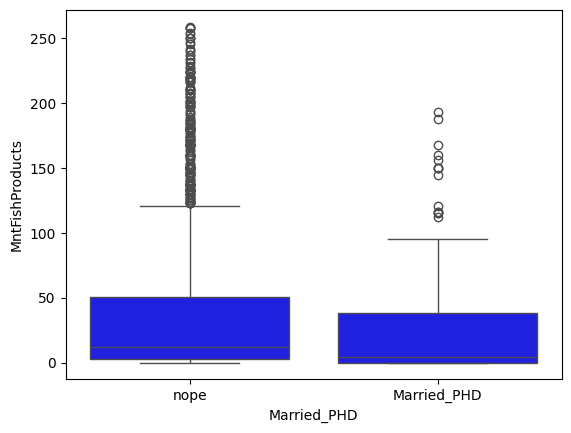

In [24]:
#Do Married PHD candidates have increased spending on fish as compared to the general population?
'''thought process - group them based on r/s status, as well as education status, and see if they have a greater proportion'''
ifood_origin['PHD_or_not'] = ['PhD' if i == 'PhD' else 'Not_PhD' for i in ifood_origin['Education']]
print(ifood_origin['Education'].unique)
ifood_origin['Married_or_not'] = ['Married' if i == 'Married' else 'Not_Married' for i in ifood_origin['Marital_Status']]
ifood_origin['Married_PHD'] = ifood_origin['PHD_or_not'] + ' ' + ifood_origin['Married_or_not']
ifood_origin['Married_PHD'] = ['Married_PHD' if i == 'PhD Married' else 'nope' for i in ifood_origin['Married_PHD']]
sns.boxplot(x = ifood_origin['Married_PHD'], y = ifood_origin['MntFishProducts'], color = 'b')

#do t test to check for randomness between samples of the variable
scipy.stats.ttest_ind(ifood_origin[ifood_origin['Married_PHD'] == 'Married_PHD']['MntFishProducts'], ifood_origin[ifood_origin['Married_PHD'] == 'nope']['MntFishProducts']).pvalue

In [ ]:
#what factors are significantly related to fish amount spendings?
'''same as factors on purchases, use heatmap or clustermap to find relationship and regression methods.'''
'''I want to do later hahahha'''

In [ ]:
#is there a sig r/s between geographical regions and success of a campaign.
'''To do: find out based on a barplot on the campaign scores grouped by regions'''
'''Note: can do addition of all values, or just filter LOL based on each campaign'''
